In [13]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
a=pd.read_excel("Downloads/stand by disel excel shet.xlsx")  
a.head(5) 

,month,load(Mw),class
0,4,40,no
1,6,50,no
2,7,80,no
3,10,100,no
4,12,120,no


In [14]:
a = a.drop(columns=["class"])
a.head()

,month,load(Mw)
0,4,40
1,6,50
2,7,80
3,10,100
4,12,120


In [21]:
import pandas as pd
a = pd.read_excel("Downloads/stand by disel excel shet.xlsx")
a.columns = a.columns.str.strip()
K = {'no': 0, 'yes': 1}
a['class'] = a['class'].str.strip().map(K)
X = a[['month', 'load(Mw)']]
y = a['class']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 0])

In [23]:
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

print("accuracy score", accuracy_score(y_test, y_pred))
print("mean_squared_error", mean_squared_error(y_test, y_pred))

accuracy score 1.0
mean_squared_error 0.0


In [26]:
y_true = y_test
data = confusion_matrix(y_true, y_pred)
data

array([[2, 0],
       [0, 1]])

In [29]:
import seaborn as sn

df_cm = pd.DataFrame(data, columns=np.unique(y_true), index=np.unique(y_true))
df_cm.index.name = "Actual"
df_cm.columns.name = "Predicted"

plt.figure(figsize=(10, 7))
sn.set(font_scale=1.4)
df_cm


Predicted,0,1
Actual,,
0,2,0
1,0,1


<Figure size 1000x700 with 0 Axes>

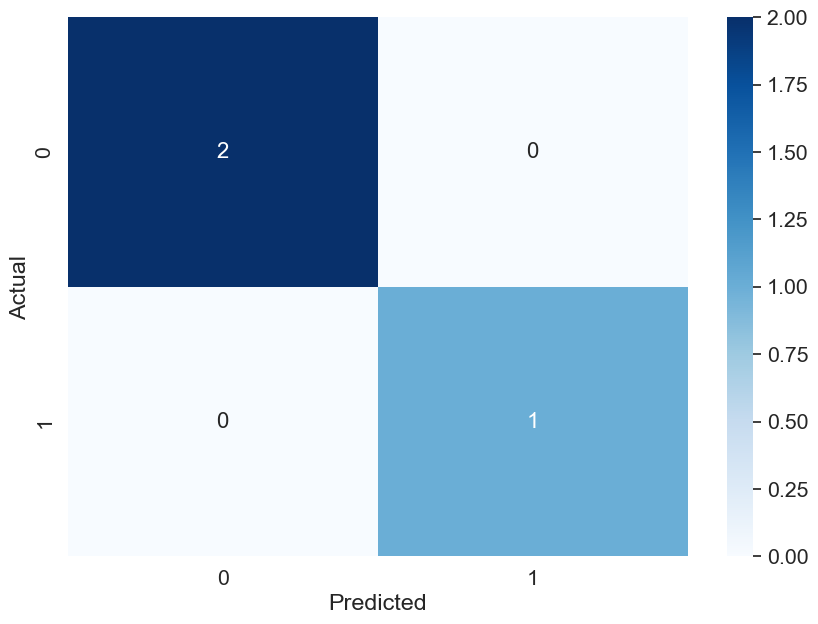

In [27]:
sn.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16})
plt.show()